# 📝 Dusha — Анализ текстовых признаков

TF-IDF важные слова, биграммы, лемматизация, облака слов.

**Эмоции**: `angry` (0), `sad` (1), `neutral` (2), `positive` (3)

**Пайплайн предобработки**:
1. Lowercase + удаление лишних пробелов
2. Маскирование командных фраз (intent masking)
3. Лемматизация (pymorphy3)
4. Повторное маскирование команд по леммам

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))

import numpy as np
import matplotlib.pyplot as plt
import re
import json
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

import seaborn as sns
sns.set_palette("husl")
plt.style.use('seaborn-v0_8-darkgrid')

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("⚠ wordcloud не установлен. pip install wordcloud")

try:
    import pymorphy3
    morph = pymorphy3.MorphAnalyzer()
    PYMORPHY_AVAILABLE = True
    print("✅ pymorphy3 загружен")
except ImportError:
    PYMORPHY_AVAILABLE = False
    morph = None
    print("⚠ pymorphy3 не установлен. Лемматизация отключена.")

from my_experiments.config_utils import DATASET_PATH, EMO2LABEL, TARGET_NAMES

EMOTION_COLORS = {
    'angry': '#FF6B6B',
    'sad': '#4ECDC4',
    'neutral': '#95A5A6',
    'positive': '#52C76E'
}

print(f"📂 Dataset path: {DATASET_PATH}")

✅ pymorphy3 загружен
📂 Dataset path: /home/natlis/PycharmProjects/dusha_new/dusha/data_processing/dataset


## 1. Стоп-слова и маскирование команд

In [3]:
RUSSIAN_STOPWORDS = {
    'я', 'ты', 'он', 'она', 'оно', 'мы', 'вы', 'они',
    'мой', 'твой', 'его', 'её', 'наш', 'ваш', 'их',
    'себя', 'меня', 'тебя', 'нас', 'вас',
    'мне', 'тебе', 'ему', 'ей', 'нам', 'вам', 'им',
    'мной', 'тобой', 'нами', 'вами', 'ими',
    'кто', 'что', 'какой', 'который', 'чей', 'где', 'когда', 'куда', 'откуда', 'почему', 'зачем',
    'в', 'на', 'с', 'к', 'у', 'из', 'от', 'по', 'за', 'о', 'об', 'до', 'при', 'через', 'между',
    'над', 'под', 'перед', 'после', 'без', 'для', 'про', 'во', 'со', 'ко',
    'и', 'а', 'но', 'или', 'либо', 'да', 'если', 'как', 'чтобы', 'когда',
    'потому', 'поэтому', 'так', 'тоже', 'также', 'зато', 'однако',
    'не', 'ни', 'бы', 'ли', 'же', 'ведь', 'даже', 'лишь', 'только', 'уже', 'ещё', 'вот',
    'быть', 'есть', 'был', 'была', 'было', 'были', 'будет', 'будут',
    'это', 'этот', 'эта', 'эти', 'тот', 'та', 'те',
    'весь', 'вся', 'всё', 'все',
    'такой', 'такая', 'такое', 'такие',
    'самый', 'самая', 'самое', 'самые',
    'может', 'можно', 'нужно', 'надо', 'стоит',
    'вообще', 'кстати', 'конечно', 'наверное',
    'алиса', 'салют', 'джой', 'siri', 'окей', 'привет', 'пожалуйста', 'спасибо',
    'включи', 'выключи', 'скажи', 'покажи', 'найди', 'открой', 'закрой',
    'сбер', 'афина', 'джа', 'command',
    'ну', 'то', 'че',
}

COMMAND_MASK_TOKEN = "<COMMAND>"
COMMAND_PHRASES = [
    "включи фильм", "включить фильм", "смотреть фильм", "посмотреть фильм",
    "включи песню", "включить песню", "новая серия", "новый серия",
    "включи канал", "включить канал", "выйти игра", "детский режим",
    "выключить игра", "найти фильм", "слушать песня", "включить мультик",
    "включить ютуба", "сезон серия", "показать фильм", "включить музыка",
    "включи музыку", "сколько год", "смотреть бесплатно", "смотреть сериал",
]
COMMAND_PATTERNS = [re.compile(rf"\b{re.escape(p)}\b", flags=re.IGNORECASE) for p in COMMAND_PHRASES]

COMMAND_VERBS = ["включить", "выключить", "найти", "показать", "смотреть",
                 "посмотреть", "слушать", "открыть", "закрыть", "выйти"]
COMMAND_OBJECTS = ["фильм", "песня", "музыка", "мультик", "канал",
                   "ютуб", "ютуба", "игра", "серия", "сезон", "режим"]
COMMAND_VERB_OBJECT_PATTERN = re.compile(
    rf"\b(?:{'|'.join(COMMAND_VERBS)})\s+(?:{'|'.join(COMMAND_OBJECTS)})\b",
    flags=re.IGNORECASE,
)

def mask_command_phrases(text, use_lemma_patterns=False):
    """Заменяет командные фразы на <COMMAND>."""
    masked = text
    for pattern in COMMAND_PATTERNS:
        masked = pattern.sub(COMMAND_MASK_TOKEN, masked)
    if use_lemma_patterns:
        masked = COMMAND_VERB_OBJECT_PATTERN.sub(COMMAND_MASK_TOKEN, masked)
    masked = re.sub(rf"(?:{re.escape(COMMAND_MASK_TOKEN)}\s*)+", f"{COMMAND_MASK_TOKEN} ", masked)
    return masked.strip()

print(f"✅ Стоп-слов: {len(RUSSIAN_STOPWORDS)}")
print(f"✅ Командных фраз: {len(COMMAND_PHRASES)}")

✅ Стоп-слов: 154
✅ Командных фраз: 24


## 2. Предобработка текста

In [4]:
def lemmatize_text(text):
    """Лемматизация текста с помощью pymorphy3."""
    if not PYMORPHY_AVAILABLE or not morph:
        return text
    words = text.split()
    lemmas = []
    for word in words:
        if word.startswith("<") and word.endswith(">"):
            lemmas.append(word)
            continue
        parsed = morph.parse(word)[0]
        lemmas.append(parsed.normal_form)
    return ' '.join(lemmas)

def preprocess_text(text, use_lemmatization=True):
    """
    Предобработка текста:
    1. Lowercase
    2. Удаление лишних пробелов
    3. Маскирование команд
    4. Лемматизация
    5. Повторное маскирование по леммам
    """
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    text = mask_command_phrases(text, use_lemma_patterns=False)
    if use_lemmatization:
        text = lemmatize_text(text)
        text = mask_command_phrases(text, use_lemma_patterns=True)
    return text

print("✅ Функции предобработки определены")

✅ Функции предобработки определены


## 3. Загрузка данных

In [5]:
DATASET_NAME = "combine_balanced_train"
TOP_K = 10

base_path = DATASET_PATH / 'processed_dataset_090'
manifest_path = base_path / 'aggregated_dataset' / f'{DATASET_NAME}.jsonl'

if not manifest_path.exists():
    print(f"❌ Манифест не найден: {manifest_path}")
    print("\nДоступные манифесты:")
    for f in (base_path / 'aggregated_dataset').glob('*.jsonl'):
        print(f"  - {f.stem}")
else:
    print(f"✅ Манифест найден: {manifest_path}")

✅ Манифест найден: /home/natlis/PycharmProjects/dusha_new/dusha/data_processing/dataset/processed_dataset_090/aggregated_dataset/combine_balanced_train.jsonl


In [6]:
def load_texts_from_manifest(manifest_path):
    """Загрузка текстов из JSONL манифеста."""
    texts, labels = [], []
    with open(manifest_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                text = data.get('speaker_text', '')
                if not isinstance(text, str) or not text.strip():
                    continue
                texts.append(text)
                labels.append(data['emotion'])
            except (json.JSONDecodeError, KeyError):
                continue
    print(f"✅ Загружено {len(texts)} текстов")
    unique, counts = np.unique(labels, return_counts=True)
    for emo, cnt in zip(unique, counts):
        print(f"  {emo:8s}: {cnt} ({cnt/len(labels)*100:.1f}%)")
    return texts, np.array(labels)

texts, labels = load_texts_from_manifest(manifest_path)

✅ Загружено 3176 текстов
  angry   : 657 (20.7%)
  neutral : 859 (27.0%)
  positive: 615 (19.4%)
  sad     : 1045 (32.9%)


## 4. Статистика текстов по эмоциям

In [7]:
for emotion in TARGET_NAMES:
    emo_texts = [t for t, l in zip(texts, labels) if l == emotion]
    if not emo_texts:
        continue
    word_counts = [len(t.split()) for t in emo_texts]
    char_counts = [len(t) for t in emo_texts]
    print(f"\n{emotion.upper()}:")
    print(f"  Текстов: {len(emo_texts)}")
    print(f"  Среднее слов: {np.mean(word_counts):.1f} (σ={np.std(word_counts):.1f})")
    print(f"  Среднее символов: {np.mean(char_counts):.1f} (σ={np.std(char_counts):.1f})")
    print(f"  Примеры:")
    for i, t in enumerate(emo_texts[:3], 1):
        preview = t[:60] + "..." if len(t) > 60 else t
        print(f"    {i}. '{preview}'")


ANGRY:
  Текстов: 657
  Среднее слов: 5.0 (σ=3.3)
  Среднее символов: 26.8 (σ=17.7)
  Примеры:
    1. 'блядь номер девять нам'
    2. 'что такое симфол блять'
    3. 'человеком можно я тебе не подошло только ты'

SAD:
  Текстов: 1045
  Среднее слов: 3.8 (σ=2.2)
  Среднее символов: 23.0 (σ=12.0)
  Примеры:
    1. 'что делать тебя хочу спать'
    2. 'нет невесты армянский сериал'
    3. 'ты что делаешь когда тебе грустно'

NEUTRAL:
  Текстов: 859
  Среднее слов: 3.9 (σ=2.0)
  Среднее символов: 23.4 (σ=12.2)
  Примеры:
    1. 'смотреть американское кино пятидесятых годов'
    2. 'внутренние органы человека'
    3. 'двадцать третья часть'

POSITIVE:
  Текстов: 615
  Среднее слов: 4.5 (σ=2.7)
  Среднее символов: 25.1 (σ=14.9)
  Примеры:
    1. 'а мой муж будет богатый'
    2. 'викинг российский исторический фильм'
    3. 'группа божья коровка друзья товарищи'


## 5. TF-IDF: важные слова по эмоциям

In [8]:
print("⏳ Предобработка текстов (лемматизация)...")
preprocessed_texts = [preprocess_text(t, use_lemmatization=True) for t in texts]
print(f"✅ Обработано {len(preprocessed_texts)} текстов")

word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=10000,
    min_df=2,
    max_df=0.7,
    sublinear_tf=True,
    stop_words=list(RUSSIAN_STOPWORDS)
)

X_word = word_vectorizer.fit_transform(preprocessed_texts)
word_features = np.array(word_vectorizer.get_feature_names_out())
print(f"✅ Word-level матрица: {X_word.shape}")

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=5000,
    min_df=2,
    max_df=0.7,
    sublinear_tf=True
)
X_char = char_vectorizer.fit_transform(preprocessed_texts)
char_features = np.array(char_vectorizer.get_feature_names_out())
print(f"✅ Char-level матрица: {X_char.shape}")

⏳ Предобработка текстов (лемматизация)...
✅ Обработано 3176 текстов
✅ Word-level матрица: (3176, 1407)
✅ Char-level матрица: (3176, 5000)


In [9]:
top_words = {}

for emotion in TARGET_NAMES:
    mask = labels == emotion
    if not mask.any():
        continue
    
    emotion_word_tfidf = X_word[mask].mean(axis=0).A1
    top_word_indices = emotion_word_tfidf.argsort()[-TOP_K:][::-1]
    top_words_list = [(word_features[idx], emotion_word_tfidf[idx], 'word') for idx in top_word_indices]
    
    emotion_char_tfidf = X_char[mask].mean(axis=0).A1
    top_char_indices = emotion_char_tfidf.argsort()[-5:][::-1]
    char_ngrams = [(char_features[idx], emotion_char_tfidf[idx], 'char') for idx in top_char_indices]
    
    top_words[emotion] = top_words_list
    
    print(f"\n{emotion.upper()} — топ-{TOP_K} слов/фраз:")
    for i, (word, score, _) in enumerate(top_words_list, 1):
        print(f"  {i:2d}. {word:30s} (TF-IDF: {score:.4f})")
    print(f"  Char n-grams:")
    for ngram, score, _ in char_ngrams:
        print(f"     '{ngram}' ({score:.4f})")


ANGRY — топ-10 слов/фраз:
   1. блядь                          (TF-IDF: 0.0348)
   2. тупой                          (TF-IDF: 0.0327)
   3. дура                           (TF-IDF: 0.0237)
   4. сказать                        (TF-IDF: 0.0229)
   5. нахуй                          (TF-IDF: 0.0165)
   6. идти                           (TF-IDF: 0.0158)
   7. разговаривать                  (TF-IDF: 0.0155)
   8. говорить                       (TF-IDF: 0.0144)
   9. нет                            (TF-IDF: 0.0128)
  10. сейчас                         (TF-IDF: 0.0126)
  Char n-grams:
     ' ты ' (0.0413)
     'ты ' (0.0413)
     ' ты' (0.0410)
     'ть ' (0.0367)
     'ать' (0.0267)

SAD — топ-10 слов/фраз:
   1. включить                       (TF-IDF: 0.0252)
   2. песня                          (TF-IDF: 0.0220)
   3. фильм                          (TF-IDF: 0.0185)
   4. мультик                        (TF-IDF: 0.0156)
   5. хотеть                         (TF-IDF: 0.0142)
   6. два            

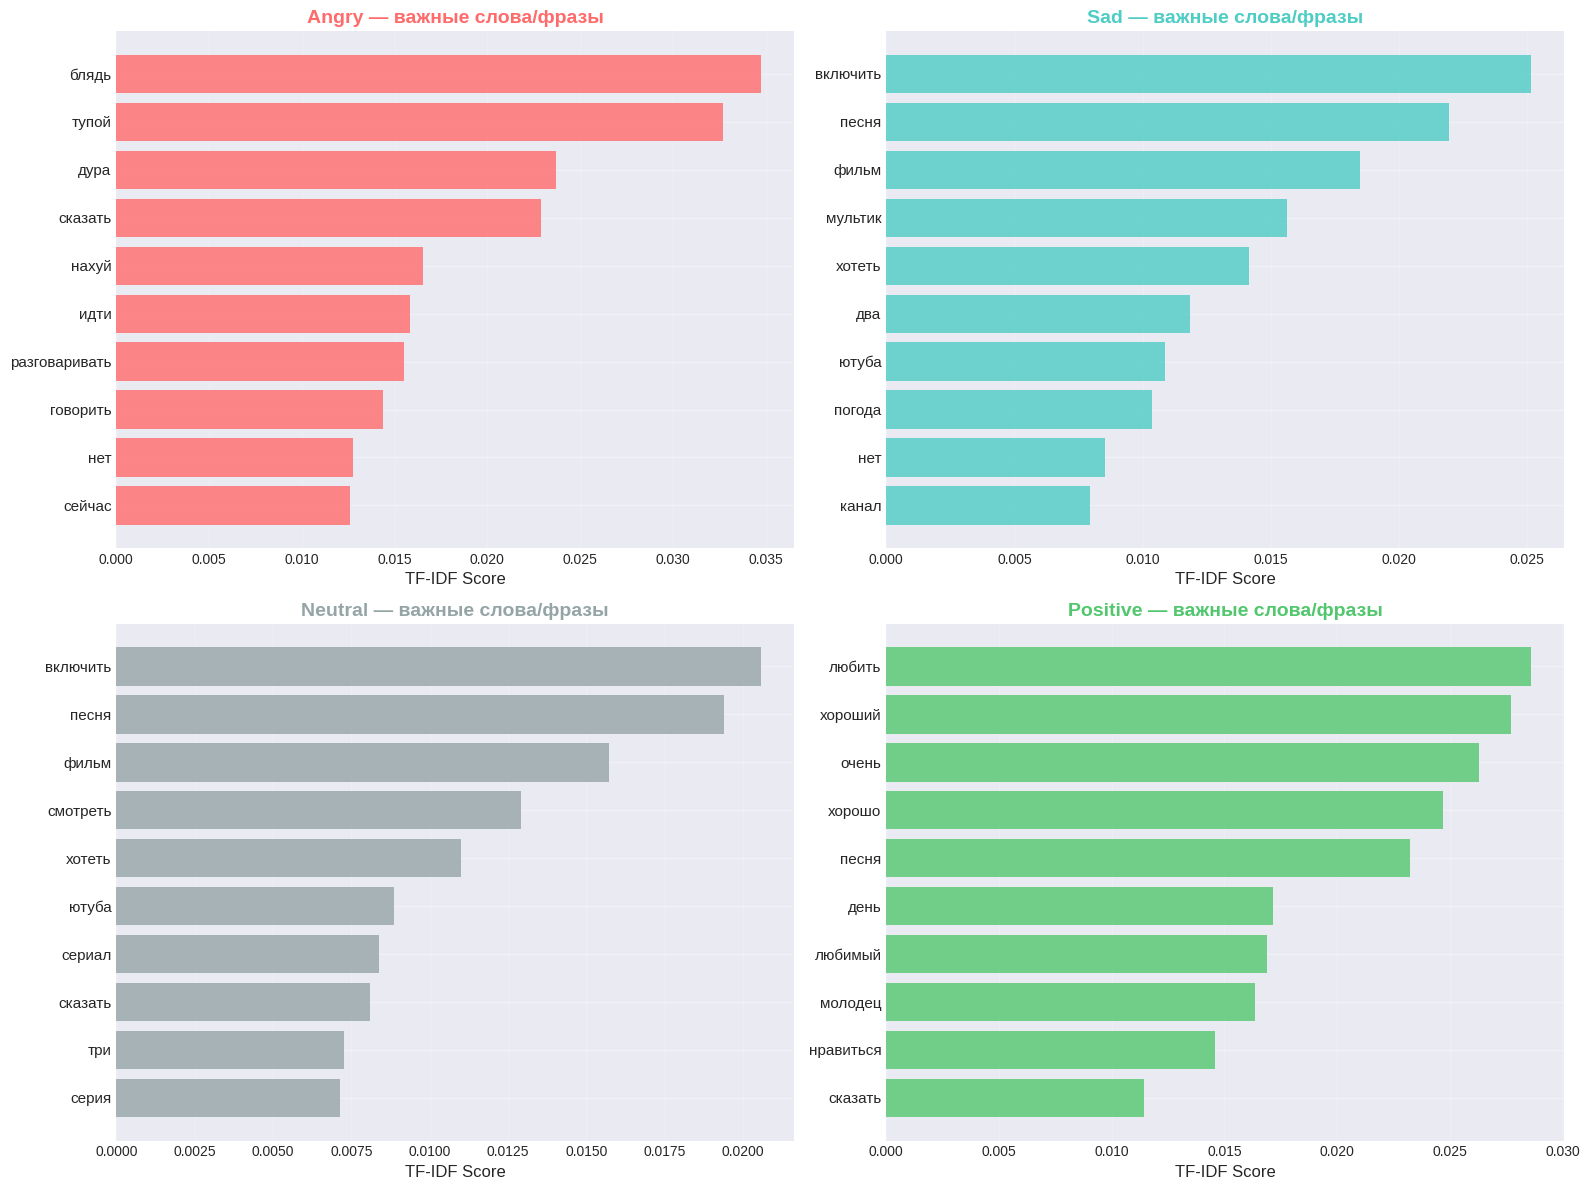

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, emotion in enumerate(TARGET_NAMES):
    if emotion not in top_words:
        continue
    ax = axes[idx]
    words = [item[0] for item in top_words[emotion]]
    scores = [item[1] for item in top_words[emotion]]
    y_pos = np.arange(len(words))
    ax.barh(y_pos, scores, color=EMOTION_COLORS[emotion], alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel('TF-IDF Score', fontsize=12)
    ax.set_title(f'{emotion.capitalize()} — важные слова/фразы',
                 fontsize=14, fontweight='bold', color=EMOTION_COLORS[emotion])
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Сравнение словарей эмоций

In [11]:
emotion_word_sets = {emo: set(w for w, s, t in words) for emo, words in top_words.items()}
emotions = list(emotion_word_sets.keys())

print("Общие слова между эмоциями:")
for i in range(len(emotions)):
    for j in range(i+1, len(emotions)):
        common = emotion_word_sets[emotions[i]] & emotion_word_sets[emotions[j]]
        if common:
            print(f"  {emotions[i]} ∩ {emotions[j]}: {', '.join(sorted(common))}")

print("\nУникальные слова (только в этой эмоции):")
for emo, words in emotion_word_sets.items():
    others = set()
    for other_emo, other_words in emotion_word_sets.items():
        if other_emo != emo:
            others |= other_words
    unique = words - others
    if unique:
        print(f"  {emo:8s}: {', '.join(sorted(unique)[:10])}")

Общие слова между эмоциями:
  angry ∩ sad: нет
  angry ∩ neutral: сказать
  angry ∩ positive: сказать
  sad ∩ neutral: включить, песня, фильм, хотеть, ютуба
  sad ∩ positive: песня
  neutral ∩ positive: песня, сказать

Уникальные слова (только в этой эмоции):
  angry   : блядь, говорить, дура, идти, нахуй, разговаривать, сейчас, тупой
  sad     : два, канал, мультик, погода
  neutral : сериал, серия, смотреть, три
  positive: день, любимый, любить, молодец, нравиться, очень, хороший, хорошо


## 7. Биграммы по эмоциям

In [12]:
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    min_df=2,
    max_df=0.5,
    stop_words=list(RUSSIAN_STOPWORDS),
    token_pattern=r'(?u)\b[а-яёa-z]{2,}\b'
)

X_bigram = bigram_vectorizer.fit_transform(preprocessed_texts)
bigram_features = np.array(bigram_vectorizer.get_feature_names_out())
print(f"✅ Найдено {len(bigram_features)} уникальных биграмм")

top_bigrams = {}
for emotion in TARGET_NAMES:
    mask = labels == emotion
    if not mask.any():
        continue
    counts = X_bigram[mask].sum(axis=0).A1
    top_idx = counts.argsort()[-TOP_K:][::-1]
    top_bigrams[emotion] = [(bigram_features[i], int(counts[i])) for i in top_idx if counts[i] > 0]
    
    print(f"\n{emotion.upper()} — топ-{TOP_K} биграмм:")
    for i, (bigram, count) in enumerate(top_bigrams[emotion], 1):
        print(f"  {i:2d}. '{bigram:25s}' (частота: {count})")

✅ Найдено 246 уникальных биграмм

ANGRY — топ-10 биграмм:
   1. 'идти нахуй               ' (частота: 5)
   2. 'ничего говорить          ' (частота: 3)
   3. 'голосовой помощник       ' (частота: 3)
   4. 'нет нет                  ' (частота: 3)
   5. 'хотеть сказать           ' (частота: 2)
   6. 'убрать ошибка            ' (частота: 2)
   7. 'пойти нахуй              ' (частота: 2)
   8. 'позвать нибыть           ' (частота: 2)
   9. 'пойти писать             ' (частота: 2)
  10. 'писать канал             ' (частота: 2)

SAD — топ-10 биграмм:
   1. 'два тысяча               ' (частота: 5)
   2. 'хотеть спать             ' (частота: 3)
   3. 'нет хотеть               ' (частота: 3)
   4. 'день рождение            ' (частота: 3)
   5. 'очень сильно             ' (частота: 3)
   6. 'первый сезон             ' (частота: 3)
   7. 'второй сезон             ' (частота: 3)
   8. 'второй серия             ' (частота: 3)
   9. 'тридцать три             ' (частота: 2)
  10. 'совсем совсем      

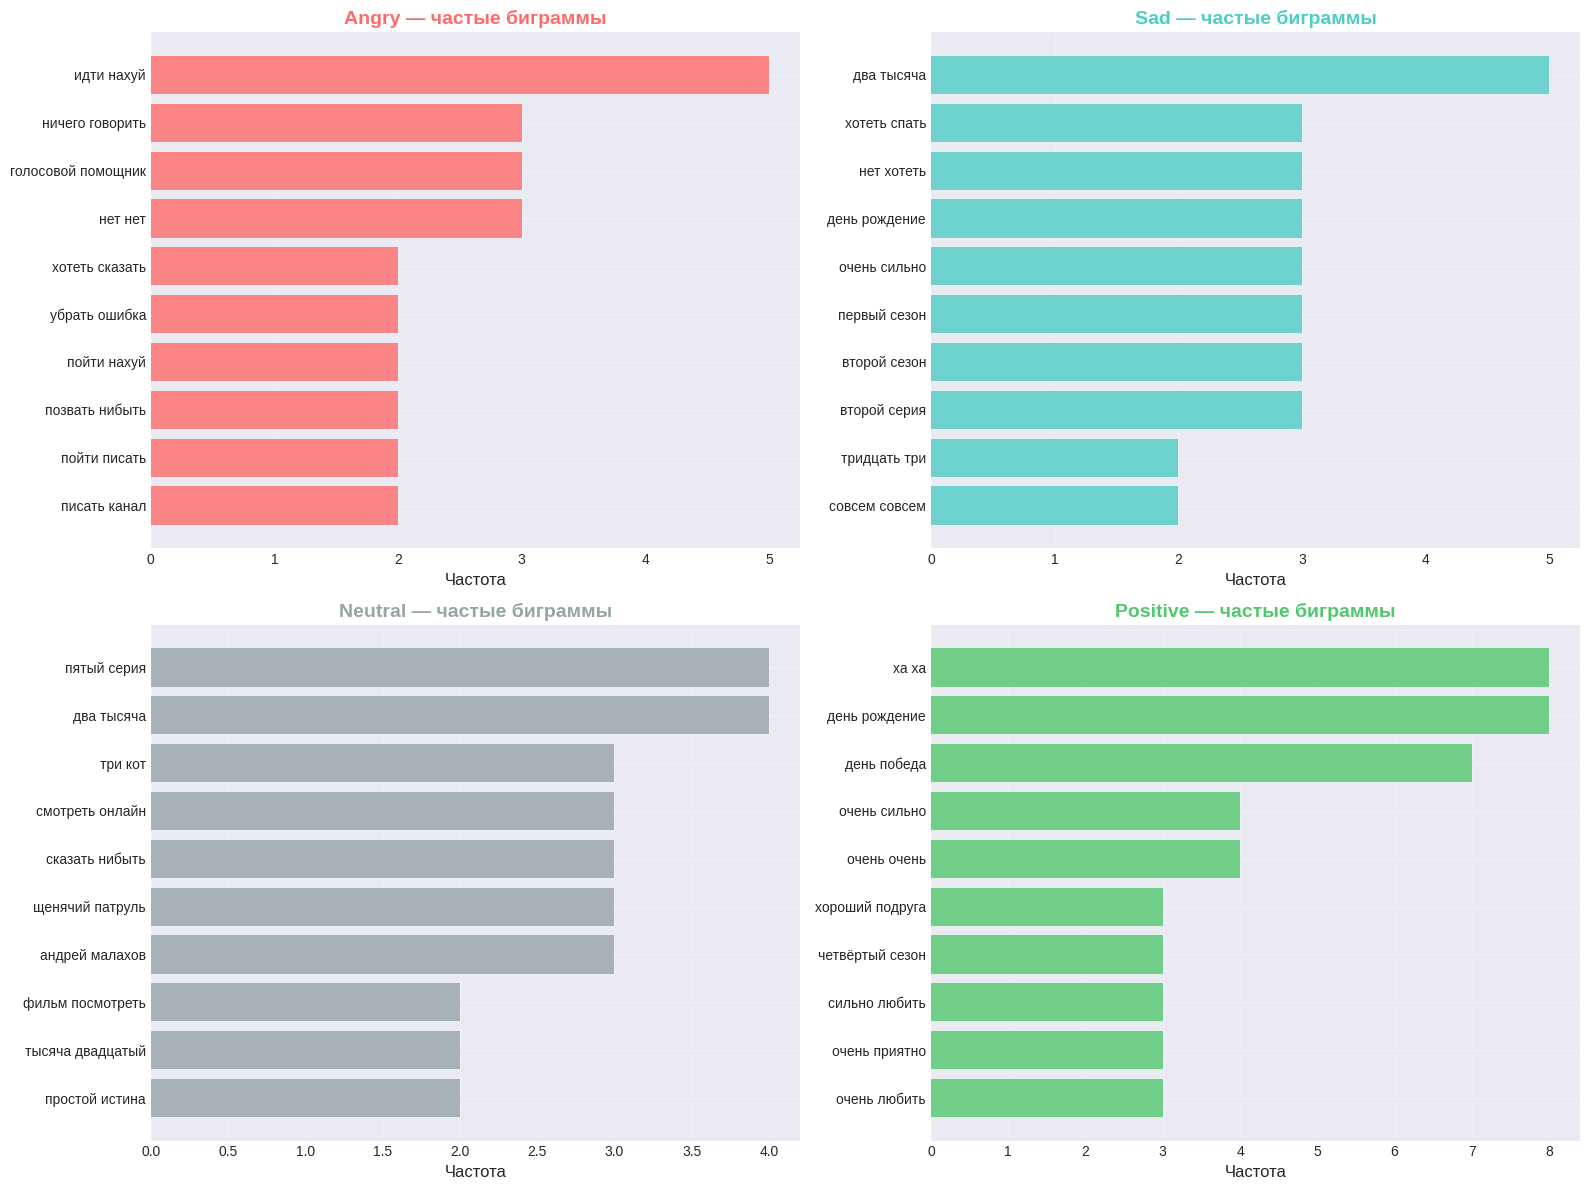

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, emotion in enumerate(TARGET_NAMES):
    if emotion not in top_bigrams or not top_bigrams[emotion]:
        continue
    ax = axes[idx]
    bigrams, counts = zip(*top_bigrams[emotion][:10])
    y_pos = np.arange(len(bigrams))
    ax.barh(y_pos, counts, color=EMOTION_COLORS[emotion], alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(list(bigrams), fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Частота', fontsize=12)
    ax.set_title(f'{emotion.capitalize()} — частые биграммы',
                 fontsize=14, fontweight='bold', color=EMOTION_COLORS[emotion])
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Облака слов (опционально)

> Требует `pip install wordcloud`

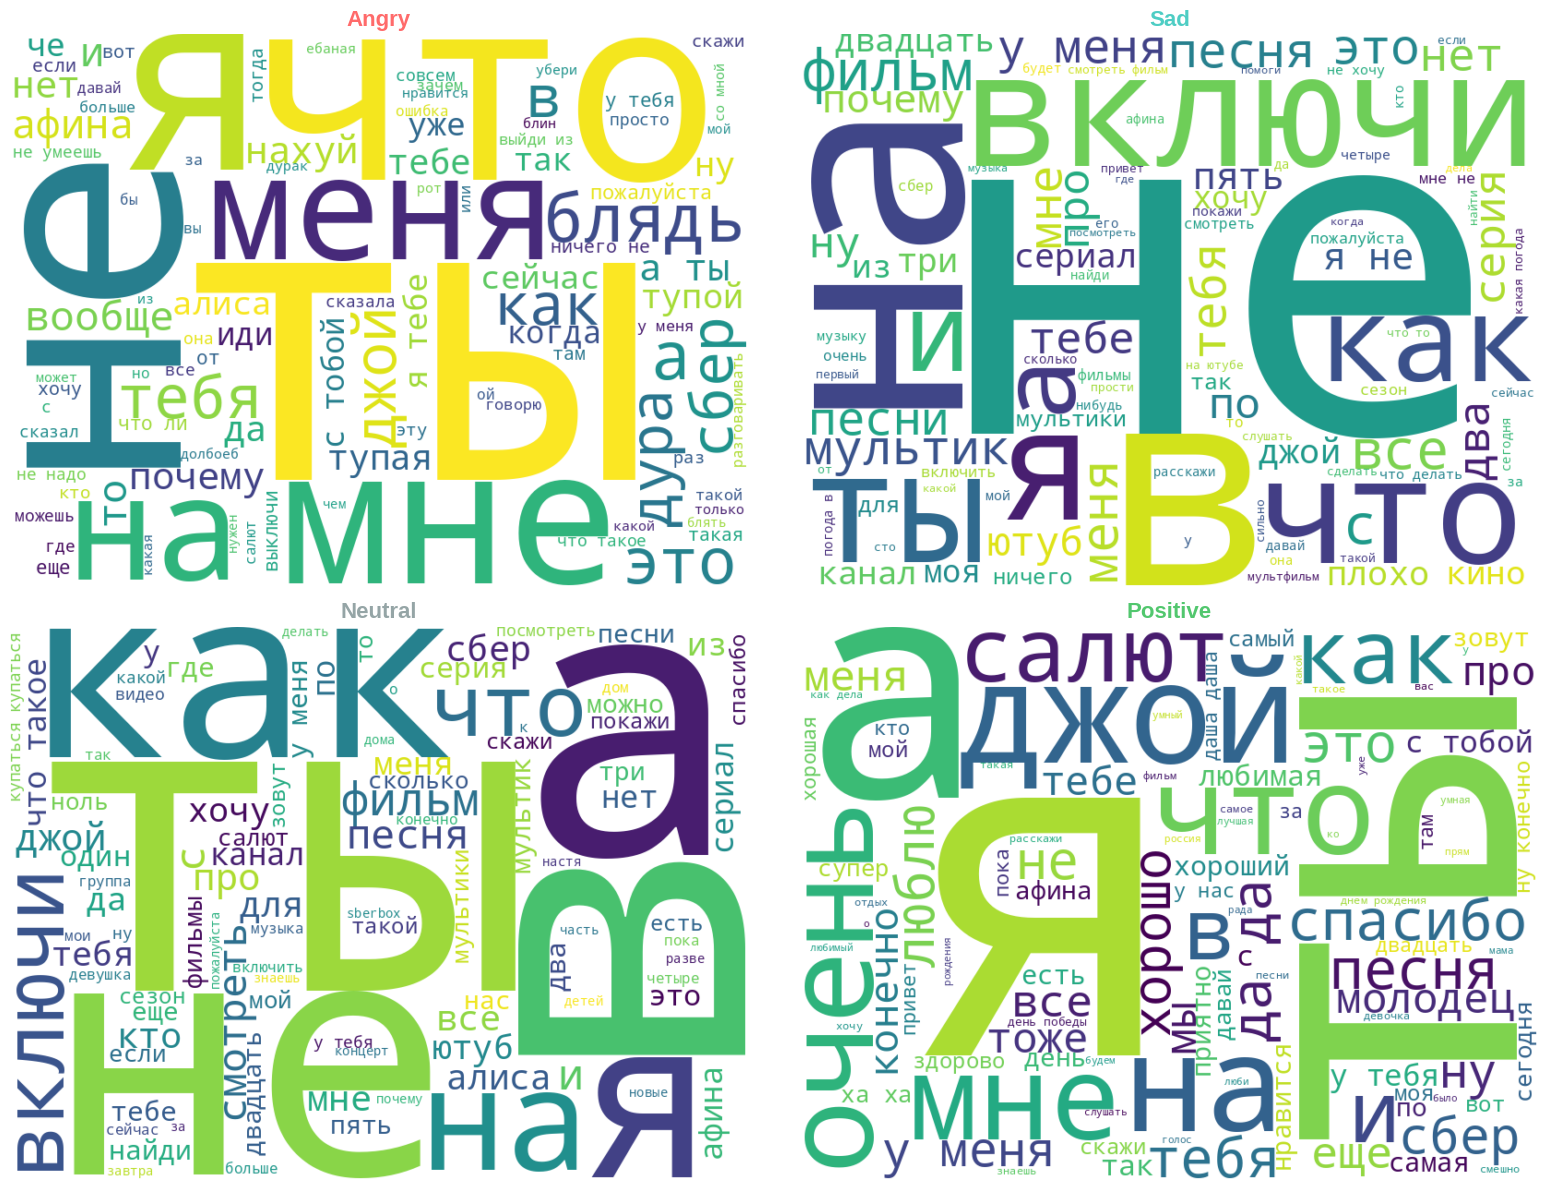

In [14]:
if WORDCLOUD_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for idx, emotion in enumerate(TARGET_NAMES):
        emo_texts = [t for t, l in zip(texts, labels) if l == emotion]
        if not emo_texts:
            continue
        wordcloud = WordCloud(
            width=800, height=600, background_color='white',
            colormap='viridis', max_words=100, relative_scaling=0.5, min_font_size=10
        ).generate(' '.join(emo_texts))
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].axis('off')
        axes[idx].set_title(f'{emotion.capitalize()}', fontsize=16, fontweight='bold',
                           color=EMOTION_COLORS[emotion])

    plt.tight_layout()
    plt.show()
else:
    print("⚠ wordcloud не установлен. Установите: pip install wordcloud")